**SEOSONAL AGRICULTURAL PERFORMANCE ANALYSIS .**

**Major Data Analytics Project **

**Domain**: Agricultural

**Project Theme**: Seasonal Agricultural performance analysis

**Tools**: Python,Panadas,numpy,matplotlib,seaborn

**Project Goal**:
The goal is to analyze how seasonal variations impact agricultural metrics to optimize farming strategies and forecast future crop yields.

**1. PROBLEM STATEMENT**

Farming isn't a one-size-fits-all business—what works in the spring often falls apart in the winter.

Between unpredictable weather, fluctuating market prices, and seasonal resource shifts, a farm's output changes drastically throughout the year.

The goal of this project is to dive into real agricultural data to understand why these seasonal swings happen.

Instead of just looking at raw numbers, we want to uncover practical patterns, see how different variables impact yield, and translate our findings into clear, evidence-based insights that can help farmers plan smarter across every season.

**2.PROJECT OBJECTIVES.**



*   **Get to know the data**: Check out how the dataset is structured and  see if there are any obvious issues or missing pieces
*   **Clean things up**: Fix errors, handle missing values, and prep everything so it is ready for analysis.


*    **Spot the seasonal trends**: Look for clear patterns that change depending on the time of year.
*  **Run the basic numbers**: Use simple stats to summarize what the data is telling you.Connect the dots



*   **Connect the dots**: See how different factors influence each other and find out what is driving the results
*   **Compare the seasons**: Pit different times of the year (or other groups) against each other to see who performs best.


*   **Make it visual**: Build clean, easy-to-read charts to show off single variables, pairs, and complex combinations.
*  **Highlight the big takeaways**: Pull out the most important and interesting insights from your findings






**3.DATASET**

This dataset contains farm level agricultural records covering different seasons, loactions,crops, environment conditions, farming practices, production, costs, revenu, profit and resource usage.

**Dataset file**: perfomance_dataset.xlsx

In [2]:
from google.colab import files
uploaded = files.upload()

Saving performance_dataset.xlsx to performance_dataset.xlsx


In [3]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:f"{x:,.2f}")


In [4]:
# load the dataset
file_path = "performance_dataset.xlsx"
df = pd.read_excel(file_path)
print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


**4.INITAL DATA UNDERSTANDING**

In [5]:
#Dataset shape
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 4000
Number of columns: 28


In [6]:
#Top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [7]:
#Bottom 5 rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [8]:
# View a random sample of 5 rows from the dataset
df.sample(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
282,SF10283,Andhra Pradesh,Nalgonda,Cotton,Kharif,4.67,"1,182.20",30.40,82.40,8.30,7.57,35.80,175.00,80.70,162.00,Flood,200.90,5.73,0.71,0.63,2.94,76487,376848,224872,-151976,3547,0.83,61.50
3698,SF13699,Maharashtra,Ludhiana,Wheat,Rabi,3.18,546.10,25.70,72.00,7.50,7.07,30.10,129.40,51.00,81.80,Rainfed,215.20,2.13,0.78,2.82,8.97,24213,236503,217191,-19312,1005,8.93,53.80
3203,SF13204,Punjab,Erode,Wheat,Zaid,9.96,345.40,31.70,60.80,8.80,7.31,24.30,120.10,83.70,49.10,Flood,240.80,5.43,0.90,1.46,14.54,22051,784673,320622,-464051,6946,2.09,37.30
127,SF10128,Tamil Nadu,Erode,Wheat,Rabi,11.28,281.90,23.40,69.30,7.40,6.62,27.20,154.30,28.40,95.30,Rainfed,154.90,5.89,0.68,2.24,25.27,27337,702245,690806,-11439,3065,8.24,31.00
20,SF10021,Punjab,Ludhiana,Rice,Rabi,0.95,409.80,23.20,58.70,7.00,7.49,24.80,85.60,88.70,83.90,Flood,206.00,2.22,0.94,1.60,1.52,20424,58222,31044,-27178,1814,0.84,45.80


In [9]:
# View the same random sample of 5 rows every time
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [10]:
# To get a simple list of column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [11]:
# To see column names, non-null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [12]:
# Check for missing values in each column
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [13]:
# Check for exact duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [14]:
# Summary statistics for numerical columns
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [15]:
# Summary statistics for text/categorical columns
df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


**5.Data Quality Analysis**

In [16]:
#missin values
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_percentage.round(2)
})

# Filter columns with missing values and sort descending
missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    by='Missing_Count', ascending=False
)

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [17]:
missing_summary.sort_values(by='Missing_Count', ascending=False)

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80
Farm_ID,0,0.00
Crop,0,0.00
District,0,0.00
Farm_Area_Hectares,0,0.00
Season,0,0.00
Avg_Temperature_C,0,0.00
Humidity_pct,0,0.00


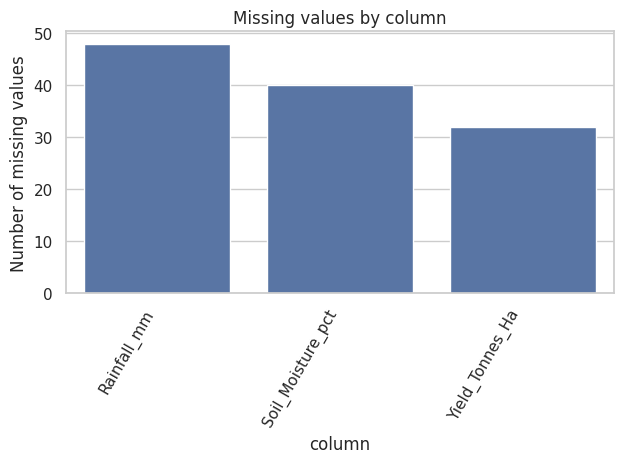

In [18]:
#visualizing missing values
plt.Figure(figsize=(12, 5))
missing_plot = missing[missing>0]
if len(missing_plot)>0:
  sns.barplot(x=missing_plot.index,y=missing_plot.values)
  plt.xticks(rotation=60,ha="right")
  plt.ylabel("Number of missing values")
  plt.xlabel("column")
  plt.title("Missing values by column")
  plt.tight_layout()
  plt.show()
else:
  print("No missing values found")

In [19]:
# Fill missing numerical values with the median of their respective columns
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

# Verify that all missing values are successfully handled
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:
Series([], dtype: int64)


In [20]:
# Re-calculate missing values
missing = df.isnull().sum()
missing_plot = missing[missing > 0]

plt.figure(figsize=(12, 5))
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of missing values")
    plt.xlabel("Column")
    plt.title("Missing values by column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found! ")

No missing values found! 


<Figure size 1200x500 with 0 Axes>

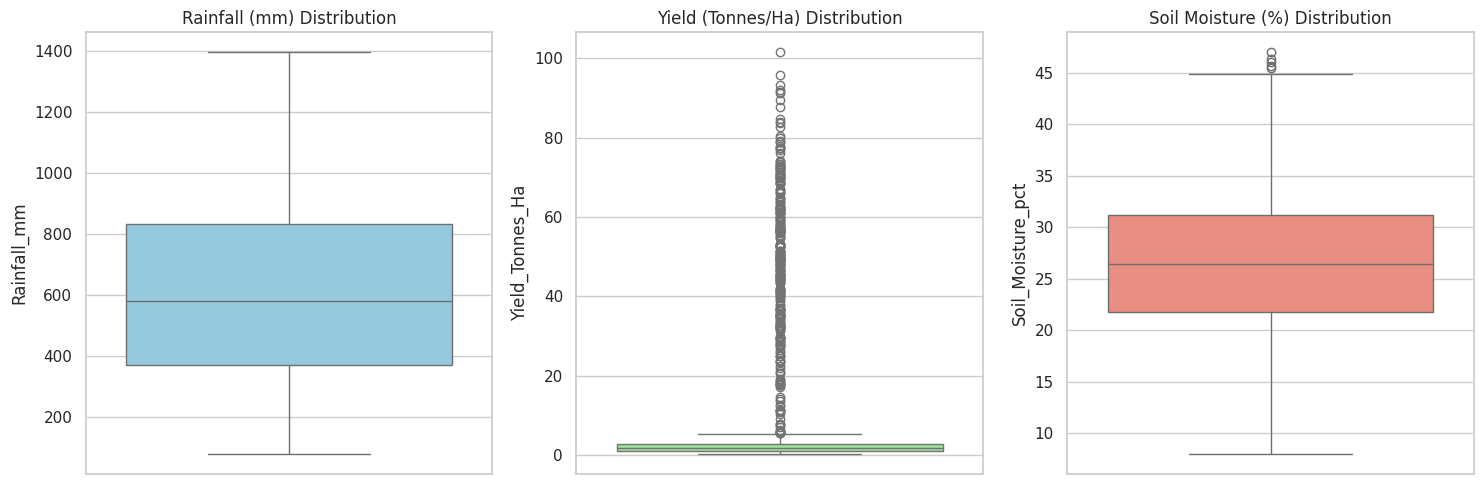

In [21]:
# Box plots to visualize data distribution and outliers
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Rainfall_mm'], color='skyblue')
plt.title('Rainfall (mm) Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Yield_Tonnes_Ha'], color='lightgreen')
plt.title('Yield (Tonnes/Ha) Distribution')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Soil_Moisture_pct'], color='salmon')
plt.title('Soil Moisture (%) Distribution')

plt.tight_layout()
plt.show()

In [22]:
#duplicate records
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:",duplicate_count)

Number of duplicate rows: 0


In [23]:
# Remove duplicate rows and update the dataset
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (4000, 28)


In [24]:
#check data types againg
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [28]:
# Get all categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Print unique values for each categorical column
for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 40)
    print(df[col].dropna().unique()[:20])

Unique values in 'Farm_ID':
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']
----------------------------------------
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']
Unique values in 'State':
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
----------------------------------------
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Unique values in 'District':
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
----------------------------------------
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
Unique values in 'Crop':
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
---------

In [29]:
#check missing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


**6.MISSING VALUE TREATMENT**

In [87]:
# Example: median imputation for numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())


print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


**FEATURE/VARIABLE REVIEW**

In [33]:
# 1. Identifier Variables
id_cols = ['Farm_ID']

# 2. Categorical Variables
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

# 3. Environmental Variables
environmental_cols = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
    'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
    'Disease_Pest_Risk_pct'
]

# 4. Operational Variables
operational_cols = [
    'Farm_Area_Hectares', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
    'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
    'Seed_Quality_Score', 'Water_Used_m3', 'Irrigation_Method'
]

# 5. Production / Performance Variables
performance_cols = [
    'Yield_Tonnes_Ha', 'Production_Tonnes', 'Water_Efficiency_t_per_1000m3'
]

# 6. Economic / Financial Variables
economic_cols = [
    'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR'
]

# ---------------------------------------------------------
# Print out the groups to verify they are stored correctly
print("Feature Classification Complete!\n")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"Environmental Features ({len(environmental_cols)}): {environmental_cols}")
print(f"Operational Features ({len(operational_cols)}): {operational_cols}")
print(f"Performance Features ({len(performance_cols)}): {performance_cols}")
print(f"Economic Features ({len(economic_cols)}): {economic_cols}")

Feature Classification Complete!

Categorical Features (5): ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
Environmental Features (7): ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Disease_Pest_Risk_pct']
Operational Features (9): ['Farm_Area_Hectares', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Water_Used_m3', 'Irrigation_Method']
Performance Features (3): ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Water_Efficiency_t_per_1000m3']
Economic Features (4): ['Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']


**7.STATISTICAL ANALYSIS**

In [88]:

# Descriptive statistics for numerical variables including skewness
numerical_df = df.select_dtypes(include=['float64', 'int64'])

desc_stats = numerical_df.describe().T
desc_stats['skewness'] = numerical_df.skew()


display(desc_stats[['count', 'mean', '50%', 'std', 'min', 'max', 'skewness']])

,count,mean,50%,std,min,max,skewness
Farm_Area_Hectares,"4,000.00",7.89,7.89,4.22,0.50,15.00,-0.04
Rainfall_mm,"4,000.00",600.92,582.00,287.19,80.00,"1,395.20",0.14
Avg_Temperature_C,"4,000.00",26.82,26.90,3.82,16.20,39.70,0.00
Humidity_pct,"4,000.00",63.21,63.00,11.96,25.00,95.00,-0.02
Sunlight_Hours_Day,"4,000.00",7.32,7.30,1.12,3.50,11.00,0.07
Soil_pH,"4,000.00",6.70,6.69,0.64,5.20,8.40,0.05
Soil_Moisture_pct,"4,000.00",26.51,26.40,6.68,8.00,47.00,-0.03
Nitrogen_kg_ha,"4,000.00",120.25,120.10,31.22,40.00,220.00,0.02
Phosphorus_kg_ha,"4,000.00",57.78,57.50,17.02,15.00,120.00,0.08
Potassium_kg_ha,"4,000.00",104.76,105.10,27.74,30.00,200.00,-0.05


In [86]:
#  numerical columns
numerical_df = df.select_dtypes(include=['float64', 'int64'])

summary_stats = numerical_df.describe().T

summary_stats = summary_stats[['mean', '50%', 'std', 'min', 'max']]

summary_stats = summary_stats.rename(columns={'50%': 'median'})


display(summary_stats)

,mean,median,std,min,max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [41]:
#seasonal descriptive summary
season_summary = df.groupby("Season")[numeric_columns].agg(["mean","median","std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

**8.UNIVARIATE ANALYSIS**

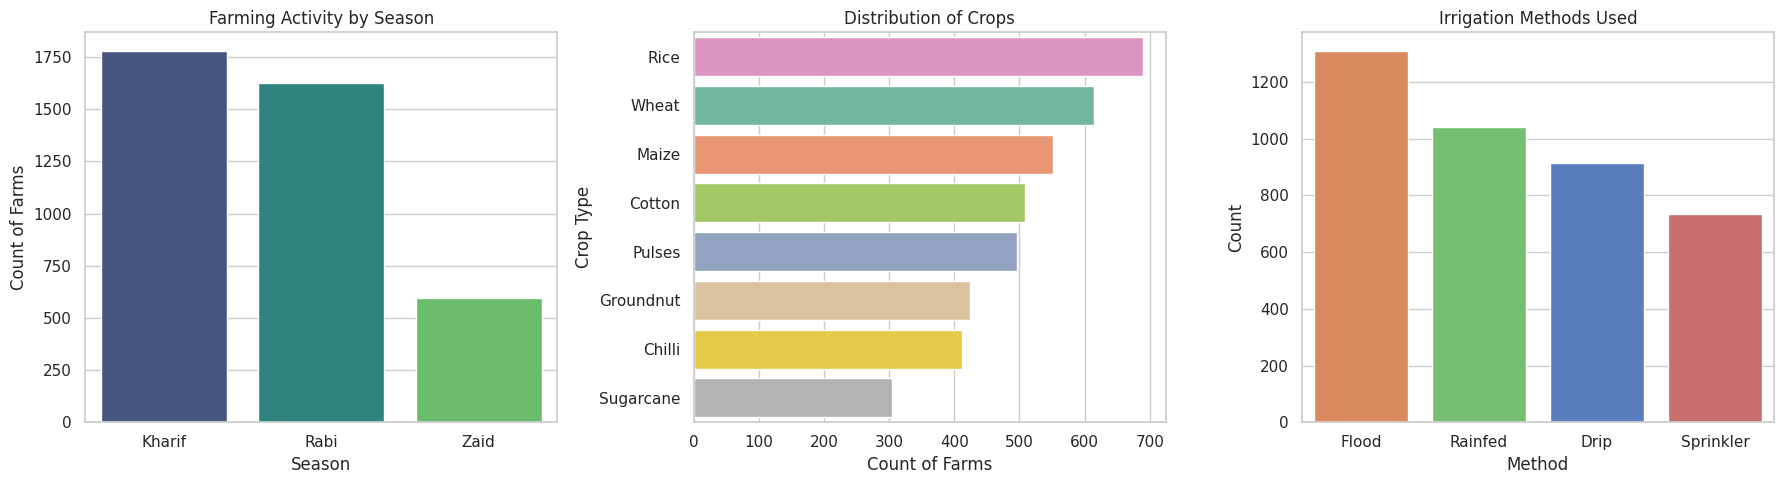

In [48]:
#univariates season distribution
sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 5))

# 1. Seasonal Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Season', hue='Season', palette='viridis', legend=False, order=df['Season'].value_counts().index)
plt.title('Farming Activity by Season')
plt.xlabel('Season')
plt.ylabel('Count of Farms')

# 2. Crop Distribution
plt.subplot(1, 3, 2)
sns.countplot(data=df, y='Crop', hue='Crop', palette='Set2', legend=False, order=df['Crop'].value_counts().index)
plt.title('Distribution of Crops')
plt.xlabel('Count of Farms')
plt.ylabel('Crop Type')

# 3. Irrigation Method
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='Irrigation_Method', hue='Irrigation_Method', palette='muted', legend=False, order=df['Irrigation_Method'].value_counts().index)
plt.title('Irrigation Methods Used')
plt.xlabel('Method')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

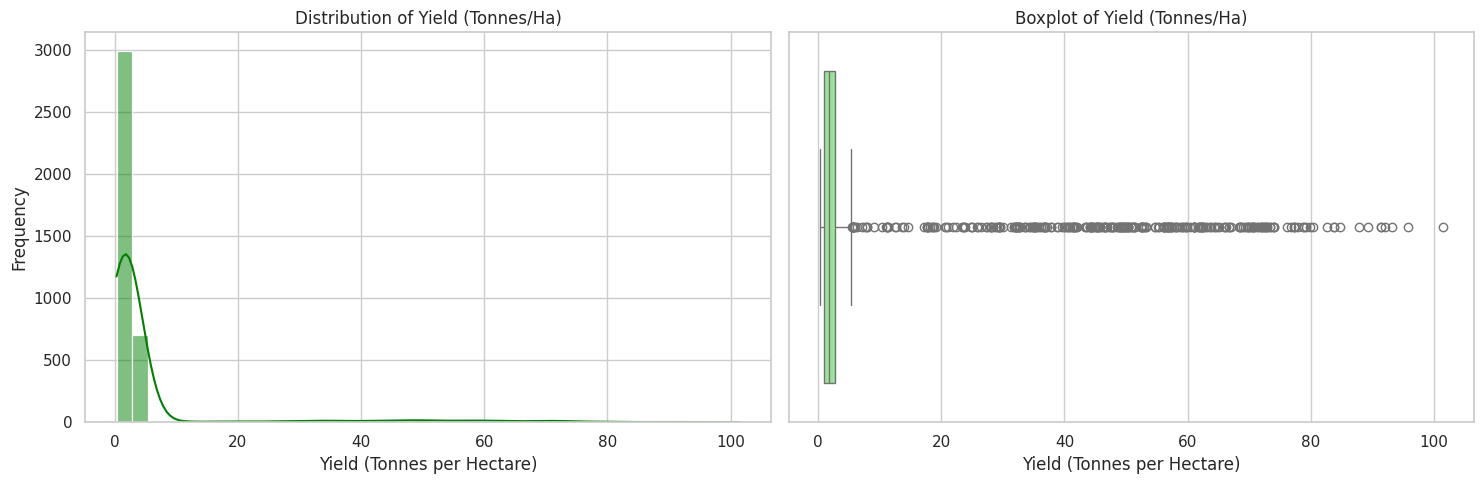

In [45]:
#  Yield distribution (Histogram + Boxplot)
plt.figure(figsize=(15, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Yield_Tonnes_Ha'], bins=40, kde=True, color='green')
plt.title('Distribution of Yield (Tonnes/Ha)')
plt.xlabel('Yield (Tonnes per Hectare)')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Yield_Tonnes_Ha'], color='lightgreen')
plt.title('Boxplot of Yield (Tonnes/Ha)')
plt.xlabel('Yield (Tonnes per Hectare)')

plt.tight_layout()
plt.show()

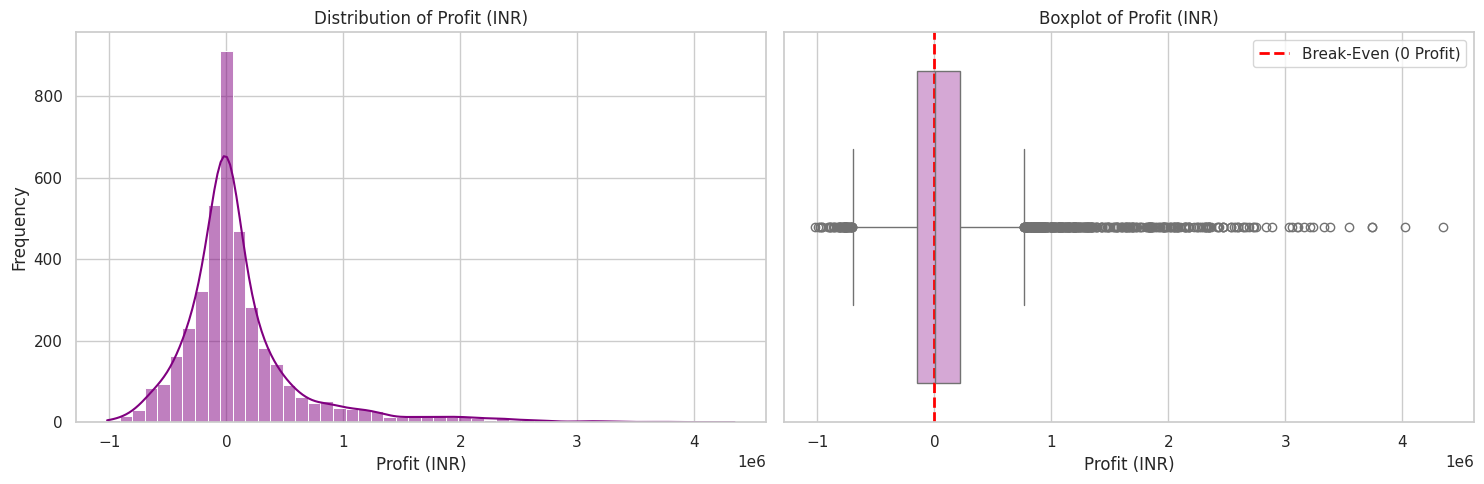

In [46]:
# Create a figure for Profit distribution (Histogram + Boxplot)
plt.figure(figsize=(15, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Profit_INR'], bins=50, kde=True, color='purple')
plt.title('Distribution of Profit (INR)')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Profit_INR'], color='plum')
plt.title('Boxplot of Profit (INR)')
plt.xlabel('Profit (INR)')

plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Break-Even (0 Profit)')
plt.legend()

plt.tight_layout()
plt.show()

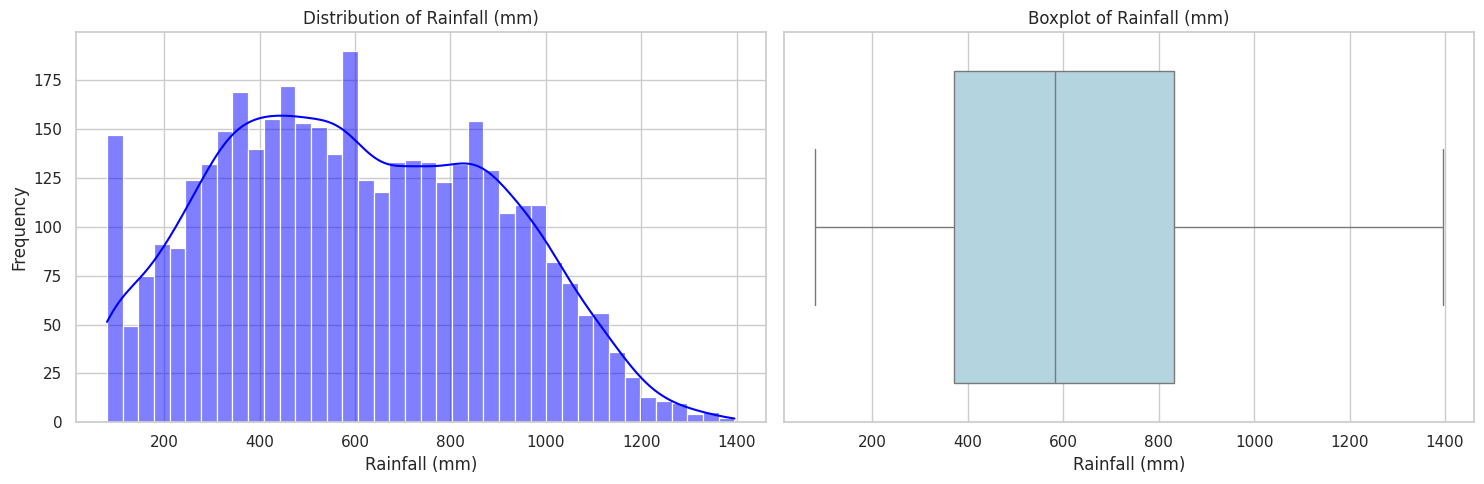

In [50]:
#  Rainfall distribution (Histogram + Boxplot)
plt.figure(figsize=(15, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Rainfall_mm'], bins=40, kde=True, color='blue')
plt.title('Distribution of Rainfall (mm)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Rainfall_mm'], color='lightblue')
plt.title('Boxplot of Rainfall (mm)')
plt.xlabel('Rainfall (mm)')

plt.tight_layout()
plt.show()

**9.OUTLIER ANALYSIS**

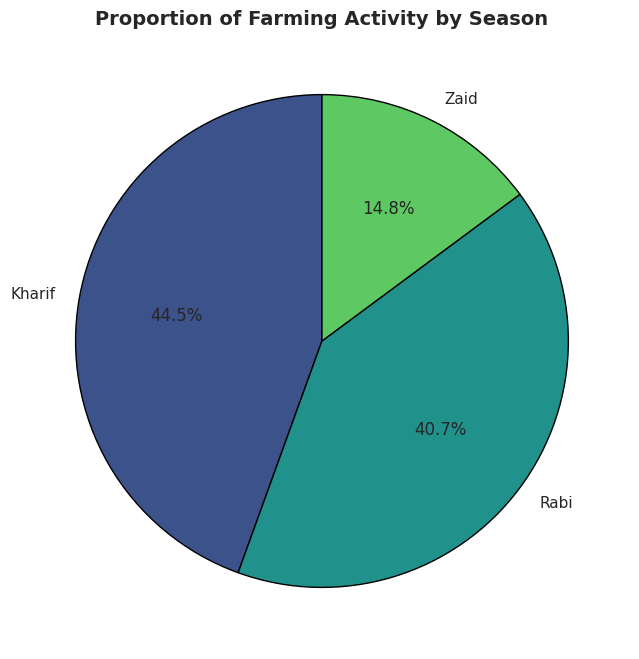

In [51]:
# Univariate: Season distribution (Pie Chart)
plt.figure(figsize=(8, 8))


season_counts = df['Season'].value_counts()

# Create the pie chart
plt.pie(season_counts,
        labels=season_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('viridis', len(season_counts)),
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Proportion of Farming Activity by Season', fontsize=14, fontweight='bold')
plt.show()

In [53]:
# IQR-based outlier summary for numerical columns
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr


    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()


    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(outlier_count / len(df) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values(
    by="Outlier Count", ascending=False
)


display(outlier_summary_df)

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


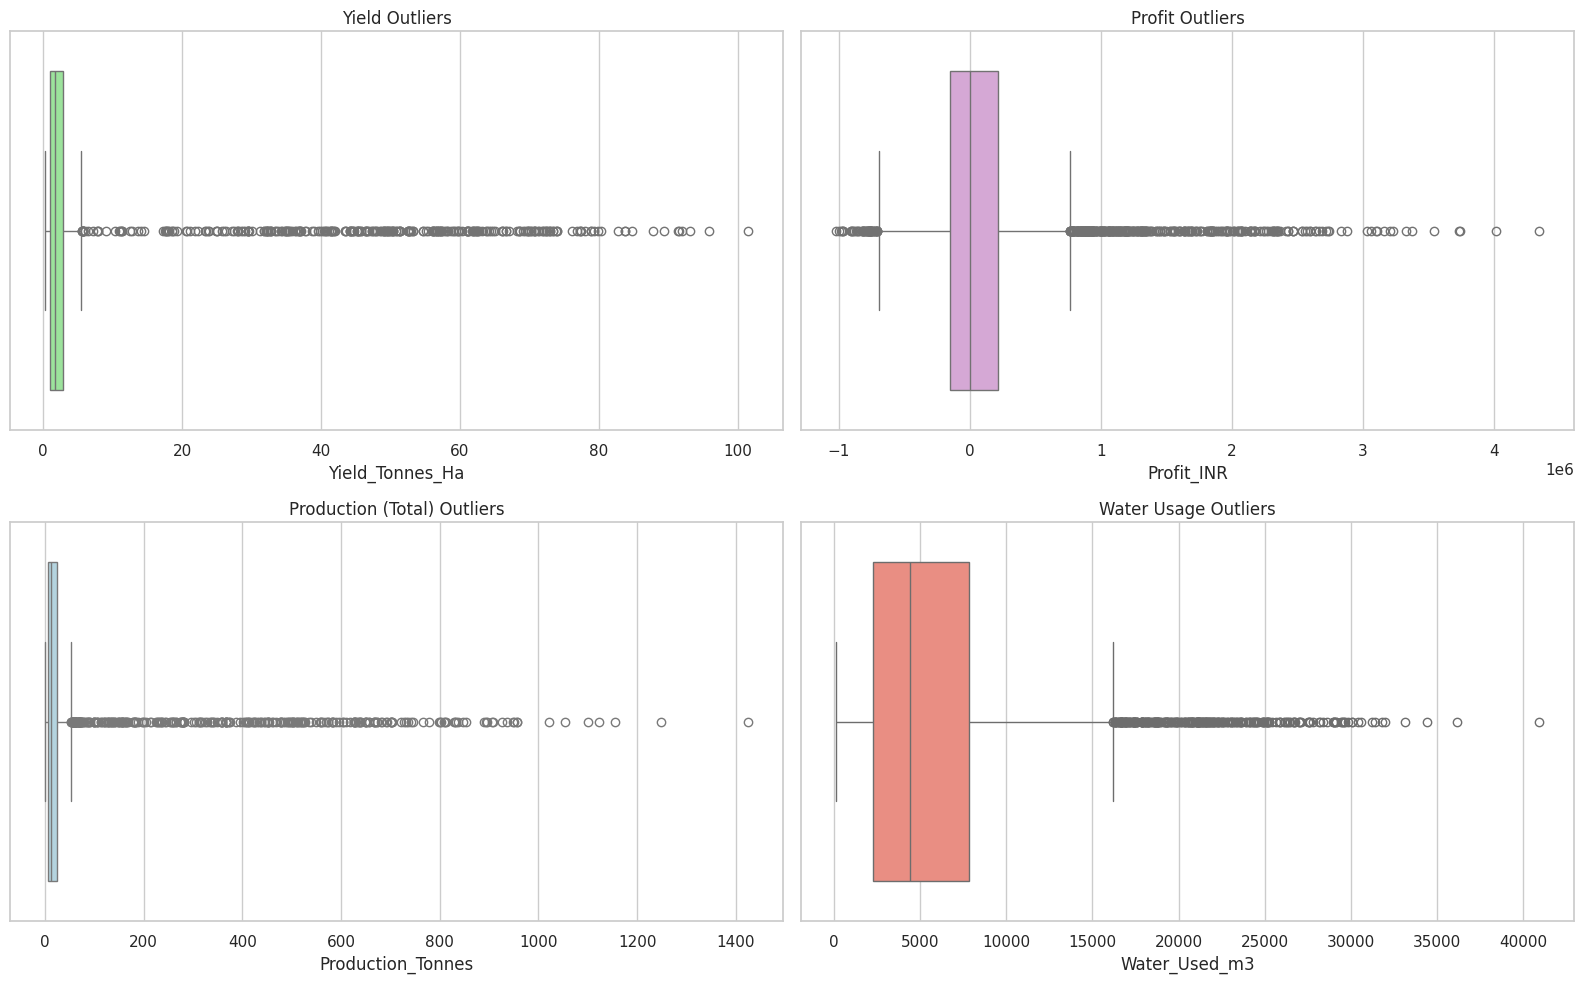

Number of Yield outliers detected (IQR method): 302
Percentage of dataset: 7.55%

Top 5 Extreme Yield Outliers (Investigating Legitimacy):


,Farm_ID,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes
1715,SF11716,Sugarcane,Kharif,6.32,101.44,641.10
3423,SF13424,Sugarcane,Kharif,14.87,95.79,"1,424.40"
3525,SF13526,Sugarcane,Rabi,6.96,93.13,648.18
1464,SF11465,Sugarcane,Kharif,7.65,91.98,703.65
3523,SF13524,Sugarcane,Kharif,0.82,91.46,75.00


In [52]:
#  VISUAL OUTLIER DETECTION ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(ax=axes[0, 0], x=df['Yield_Tonnes_Ha'], color='lightgreen')
axes[0, 0].set_title('Yield Outliers')

sns.boxplot(ax=axes[0, 1], x=df['Profit_INR'], color='plum')
axes[0, 1].set_title('Profit Outliers')

sns.boxplot(ax=axes[1, 0], x=df['Production_Tonnes'], color='lightblue')
axes[1, 0].set_title('Production (Total) Outliers')

sns.boxplot(ax=axes[1, 1], x=df['Water_Used_m3'], color='salmon')
axes[1, 1].set_title('Water Usage Outliers')

plt.tight_layout()
plt.show()

print("="*60)

# --- 2. STATISTICAL OUTLIER DETECTION (IQR Method) ---

Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers_yield = df[(df['Yield_Tonnes_Ha'] < lower_bound) | (df['Yield_Tonnes_Ha'] > upper_bound)]

print(f"Number of Yield outliers detected (IQR method): {len(outliers_yield)}")
print(f"Percentage of dataset: {(len(outliers_yield)/len(df))*100:.2f}%\n")

print("Top 5 Extreme Yield Outliers (Investigating Legitimacy):")
display(outliers_yield[['Farm_ID', 'Crop', 'Season', 'Farm_Area_Hectares', 'Yield_Tonnes_Ha', 'Production_Tonnes']].sort_values(by='Yield_Tonnes_Ha', ascending=False).head())

**10.BIVARIATE ANALYSIS**

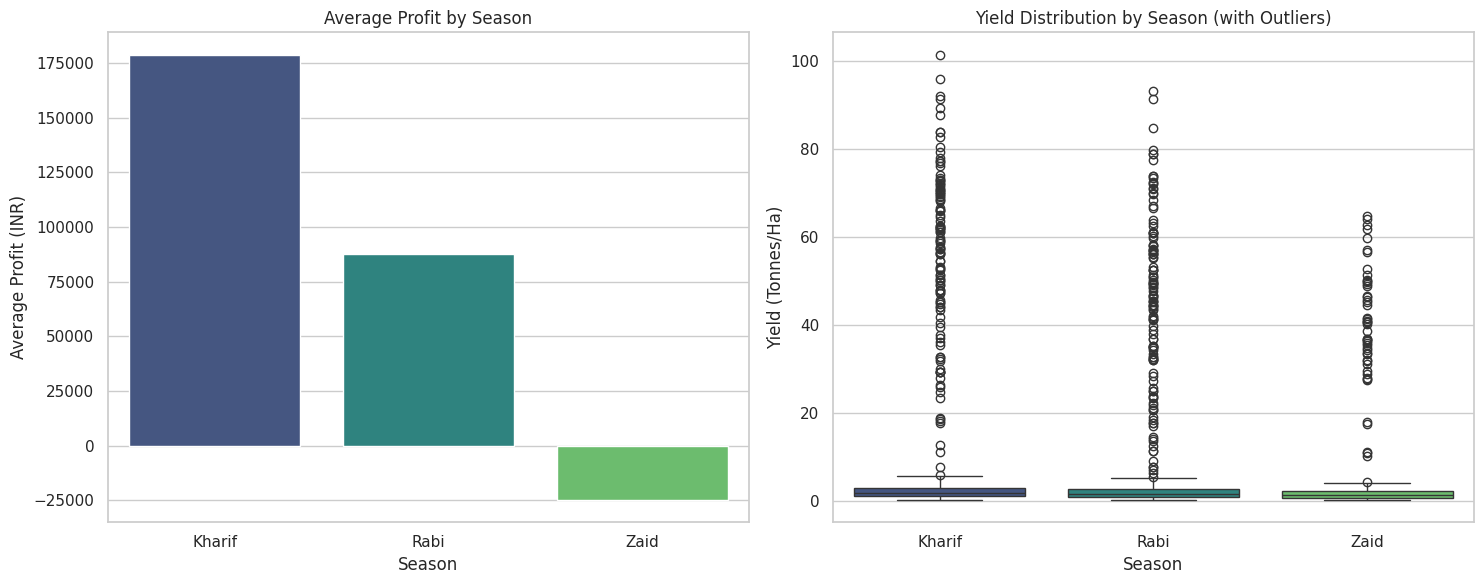

In [55]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Season', y='Profit_INR', hue='Season', palette='viridis', legend=False, errorbar=None)
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')


plt.subplot(1, 2, 2)

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', palette='viridis', legend=False)
plt.title('Yield Distribution by Season (with Outliers)')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

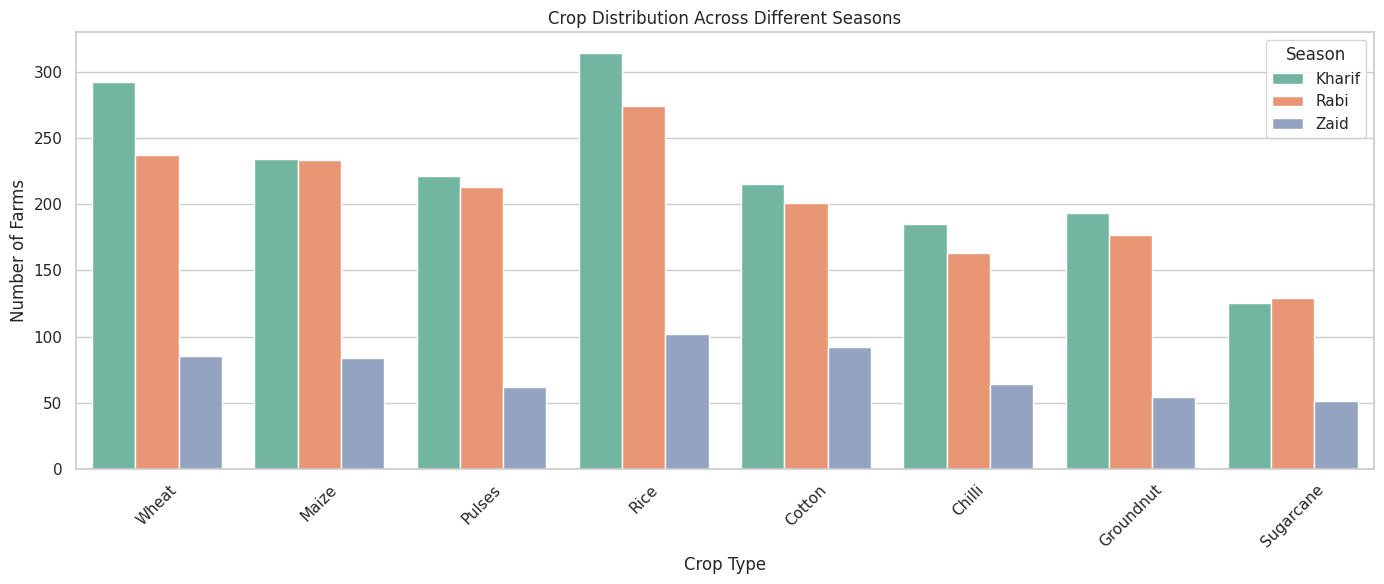

In [57]:
# plot to see which crops are grown in which seasons
plt.figure(figsize=(14, 6))

sns.countplot(data=df, x='Crop', hue='Season', palette='Set2')
plt.title('Crop Distribution Across Different Seasons')
plt.xlabel('Crop Type')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)
plt.legend(title='Season')

plt.tight_layout()
plt.show()

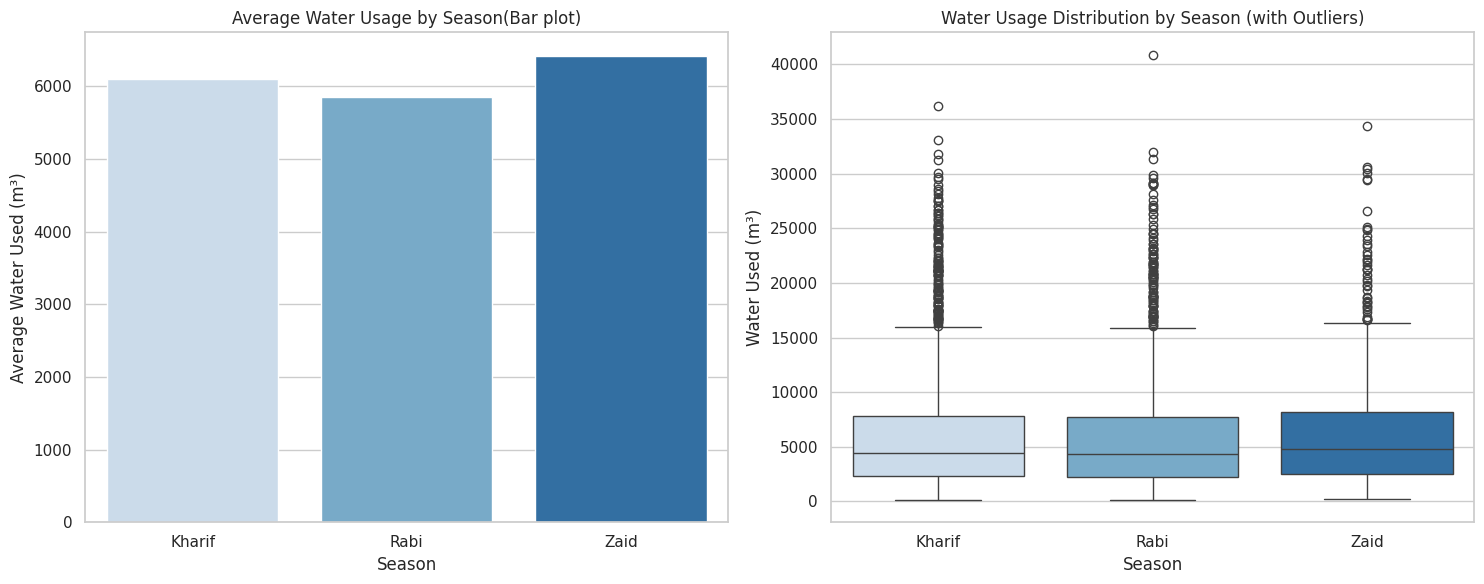

In [61]:

sns.set_theme(style="whitegrid")

#  subplots for Season vs Water Usage
plt.figure(figsize=(15, 6))

# 1. Average Water Usage by Season (Barplot)
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Season', y='Water_Used_m3', hue='Season', palette='Blues', legend=False, errorbar=None)
plt.title('Average Water Usage by Season(Bar plot)')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')

# 2. Water Usage Distribution by Season (Boxplot)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Season', y='Water_Used_m3', hue='Season', palette='Blues', legend=False)
plt.title('Water Usage Distribution by Season (with Outliers)')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.tight_layout()
plt.show()

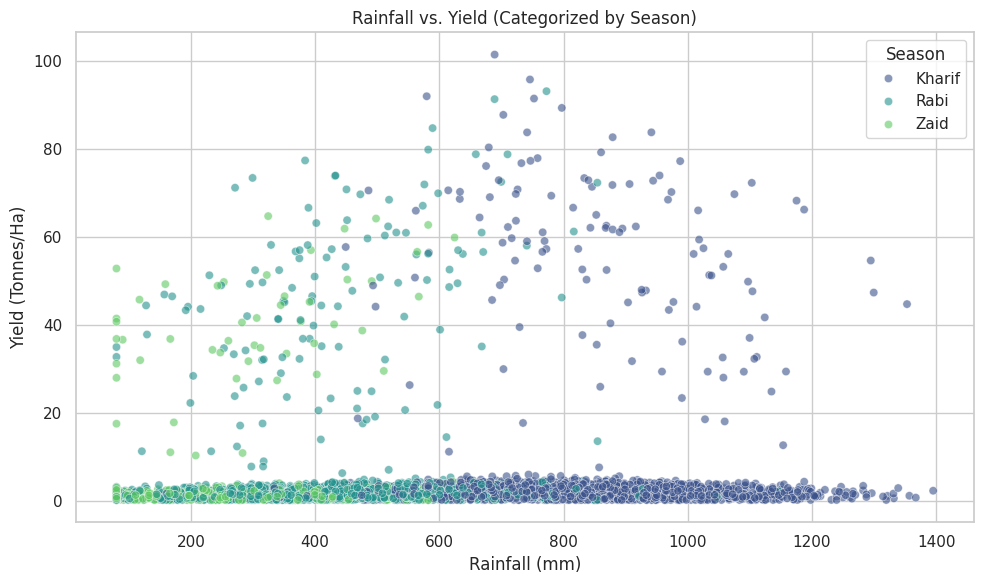

In [59]:
# a scatter plot to view the relationship between Rainfall and Yield
plt.figure(figsize=(10, 6))

# Using a scatterplot with a hue to distinguish seasons
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6, palette='viridis')
plt.title('Rainfall vs. Yield (Categorized by Season)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

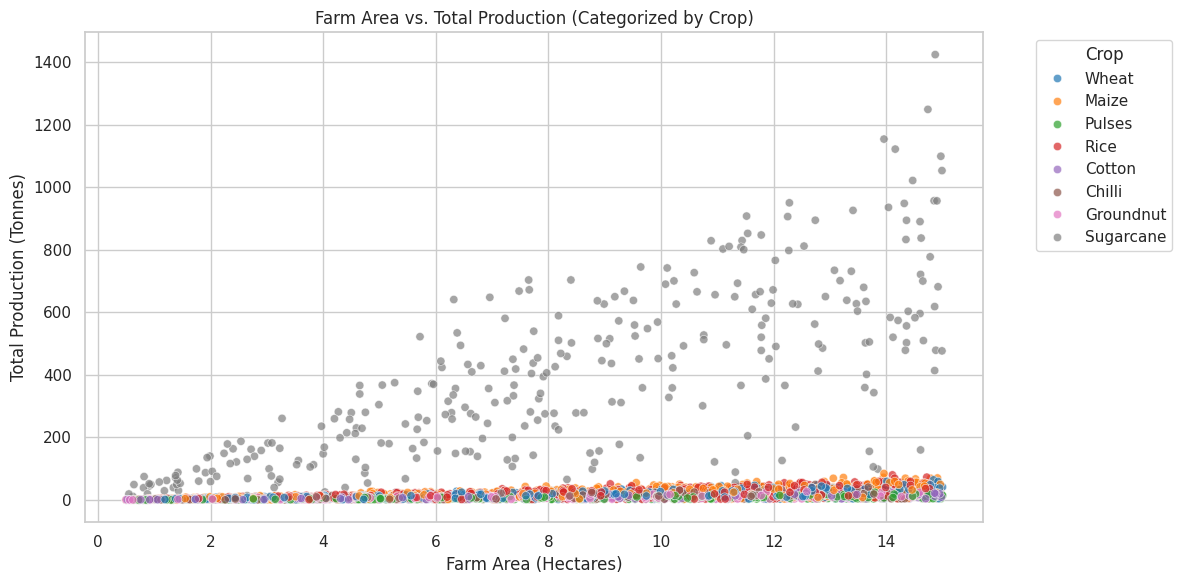

In [62]:

sns.set_theme(style="whitegrid")

# a scatter plot for Farm Area vs Production
plt.figure(figsize=(12, 6))

# scatterplot with a hue to distinguish Crop types
sns.scatterplot(data=df, x='Farm_Area_Hectares', y='Production_Tonnes', hue='Crop', alpha=0.7, palette='tab10')

plt.title('Farm Area vs. Total Production (Categorized by Crop)')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Total Production (Tonnes)')

# Place legend outside the plot so it doesn't overlap the data
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

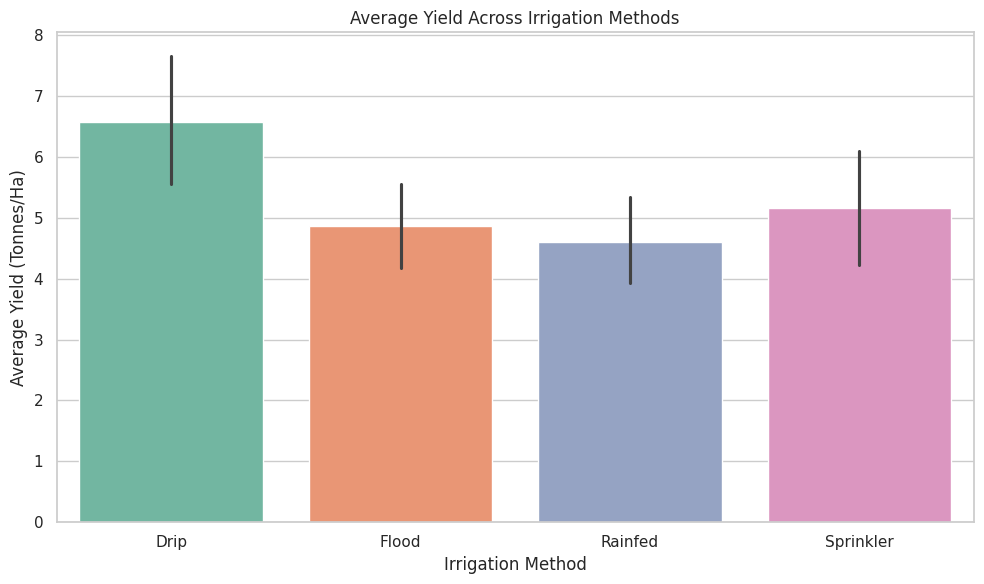

In [64]:

sns.set_theme(style="whitegrid")

#  bar plot
plt.figure(figsize=(10, 6))


sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', hue='Irrigation_Method', palette='Set2', legend=False)

plt.title('Average Yield Across Irrigation Methods')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

**11.MULTIVARIATE ANALYSIS**

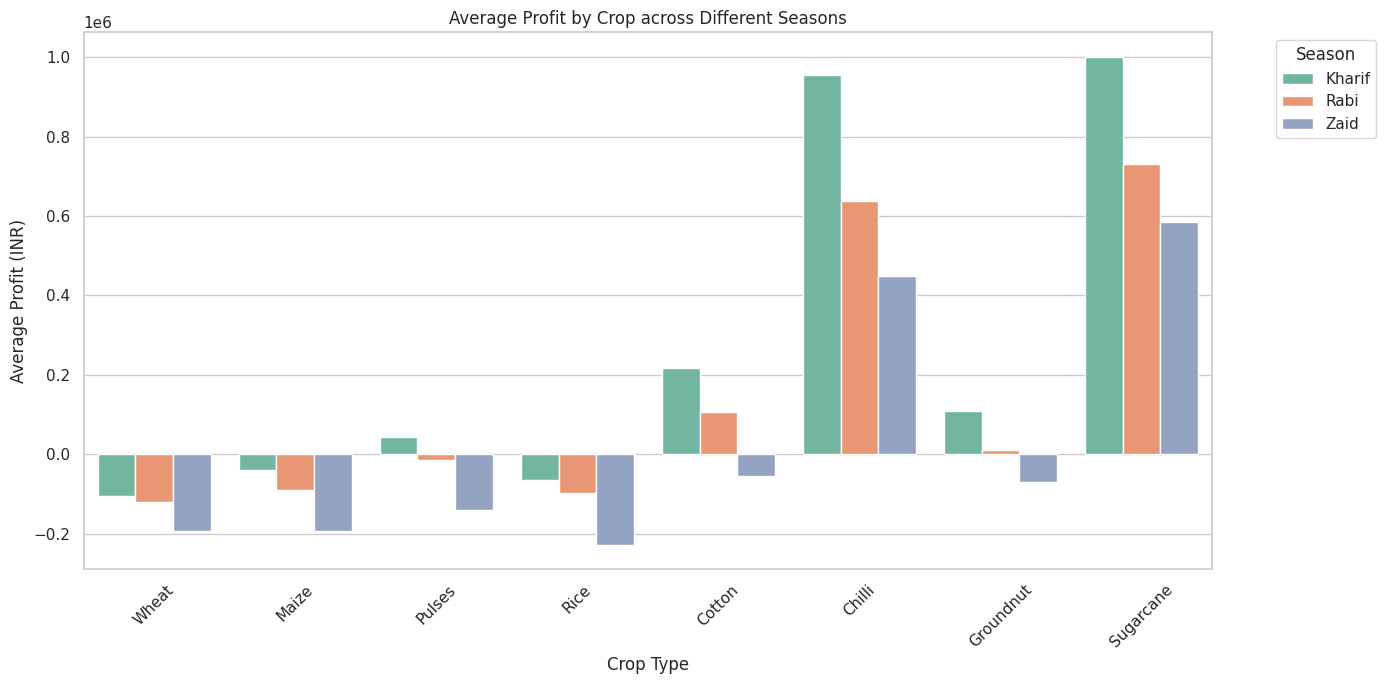

In [65]:

sns.set_theme(style="whitegrid")


plt.figure(figsize=(14, 7))

sns.barplot(data=df, x='Crop', y='Profit_INR', hue='Season', palette='Set2', errorbar=None)

plt.title('Average Profit by Crop across Different Seasons')
plt.xlabel('Crop Type')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

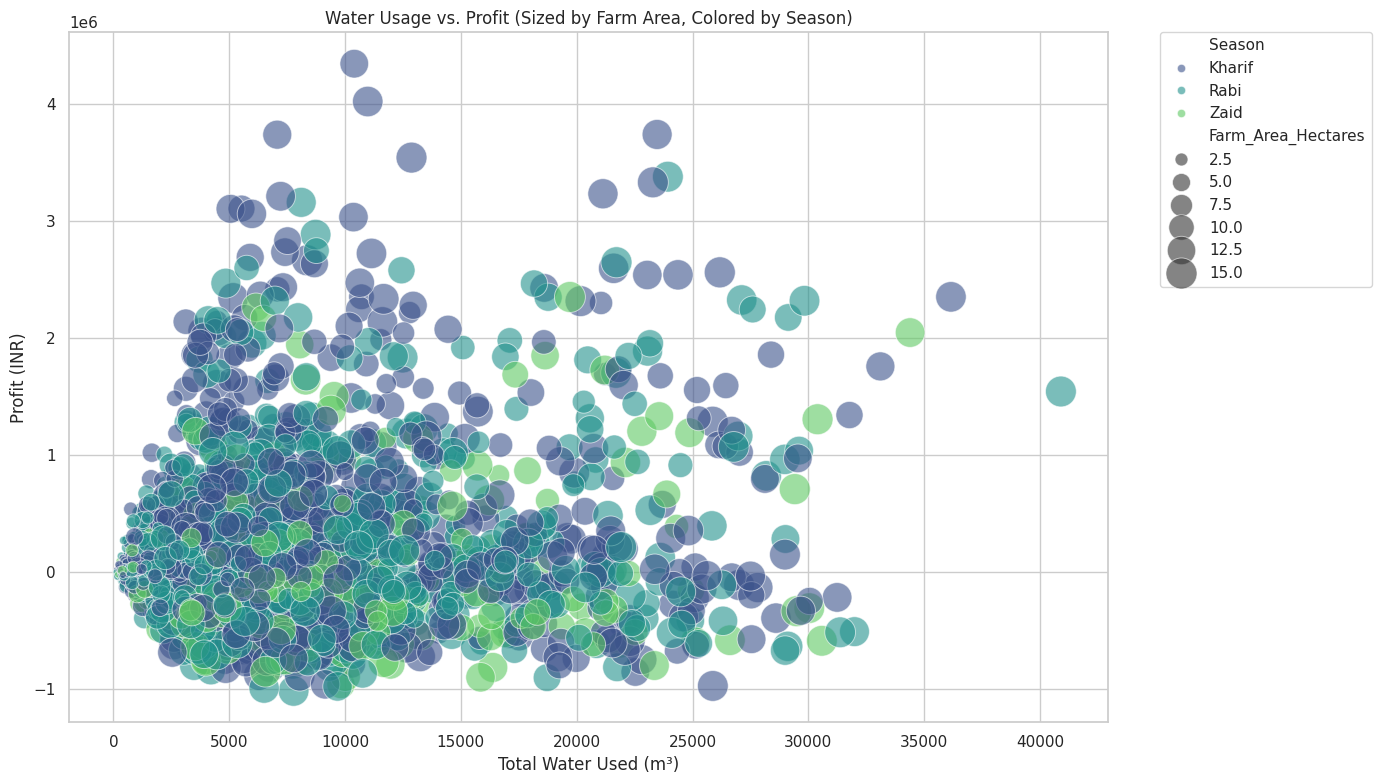

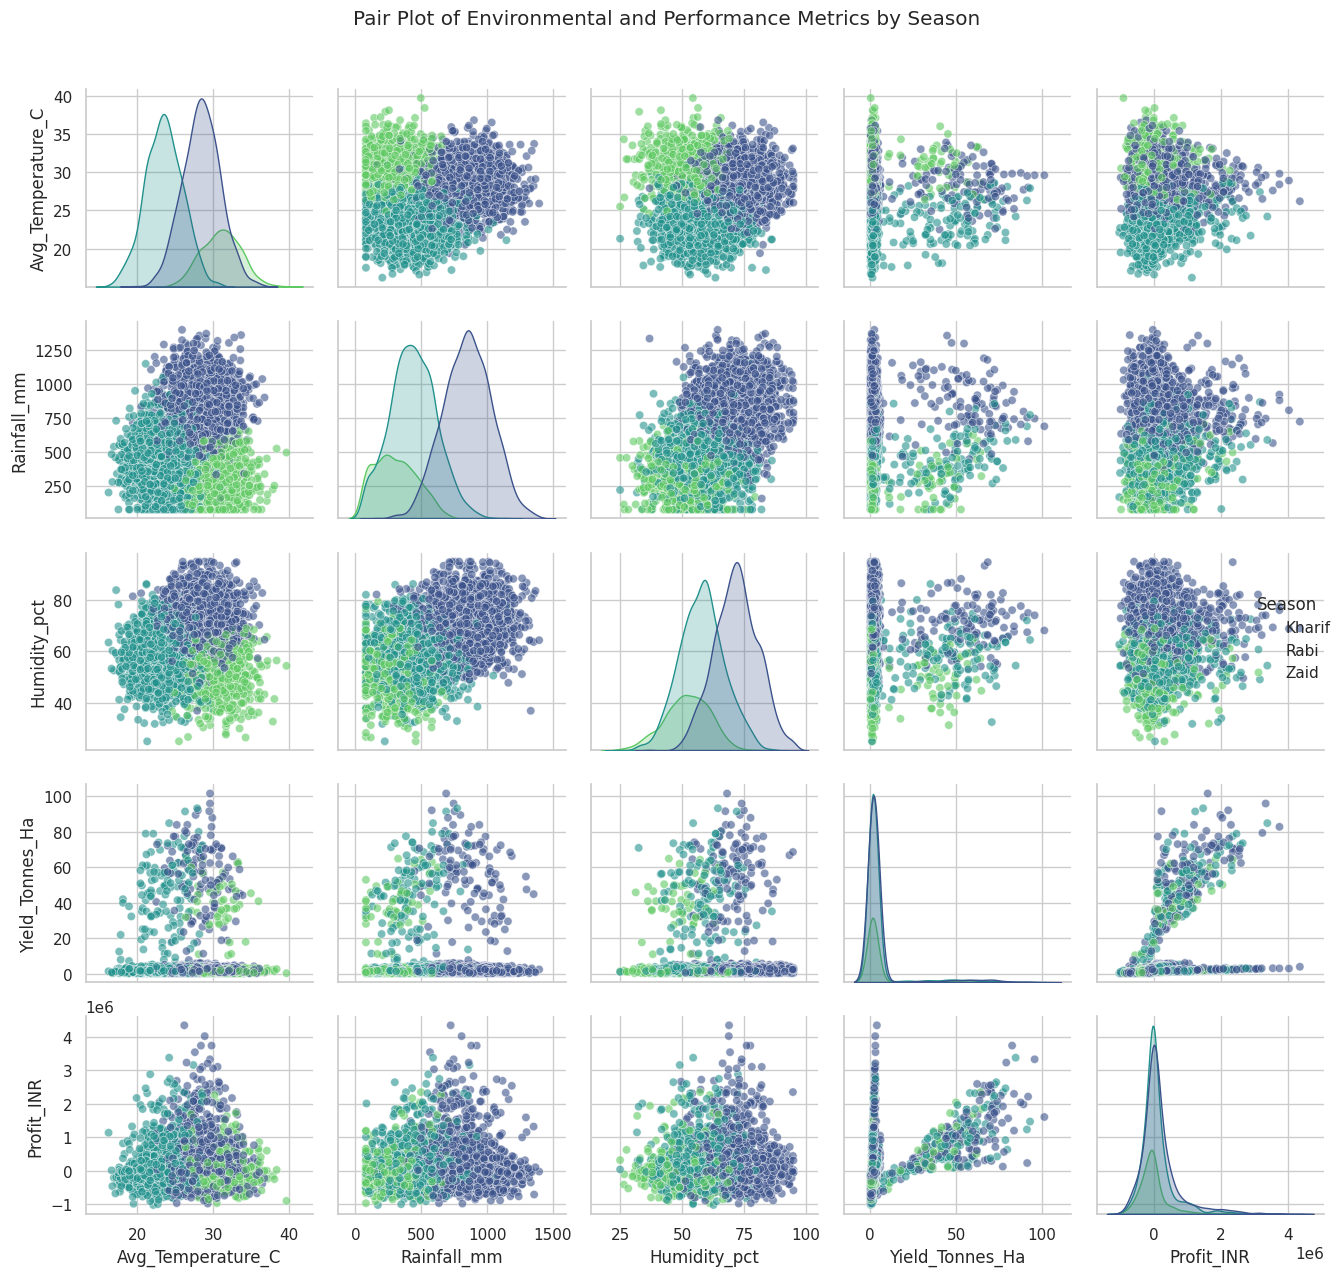

In [69]:
# --- 1. Bubble Chart: Water Usage vs. Profit (Sized by Farm Area, Colored by Season) ---
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Profit_INR',
    hue='Season',
    size='Farm_Area_Hectares',
    sizes=(20, 500),
    alpha=0.6,
    palette='viridis'
)

plt.title('Water Usage vs. Profit (Sized by Farm Area, Colored by Season)')
plt.xlabel('Total Water Used (m³)')
plt.ylabel('Profit (INR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

# --- 2. Pair Plot: Environmental & Performance Metrics by Season ---
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']

g = sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02)

plt.tight_layout()
plt.show()

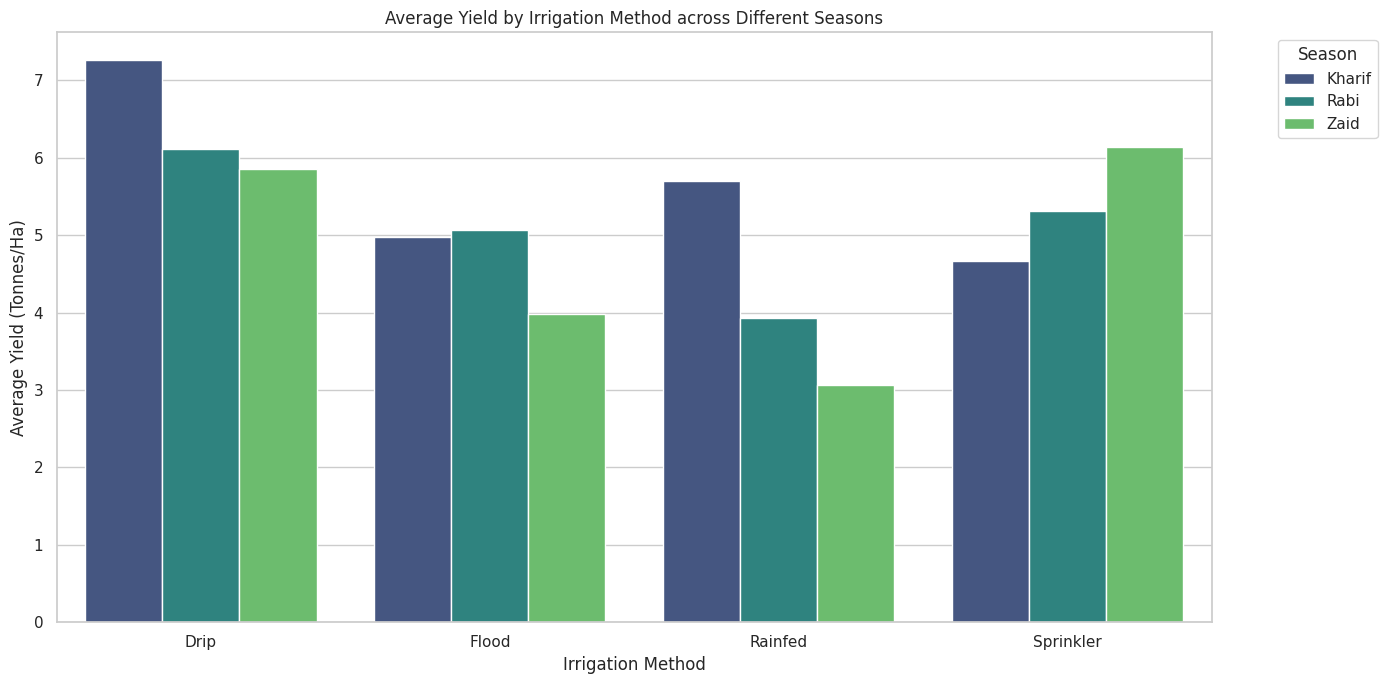

In [71]:
# Multivariate Analysis: Season, Irrigation Method, and Yield
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha',
    hue='Season',
    palette='viridis',
    errorbar=None
)

plt.title('Average Yield by Irrigation Method across Different Seasons')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

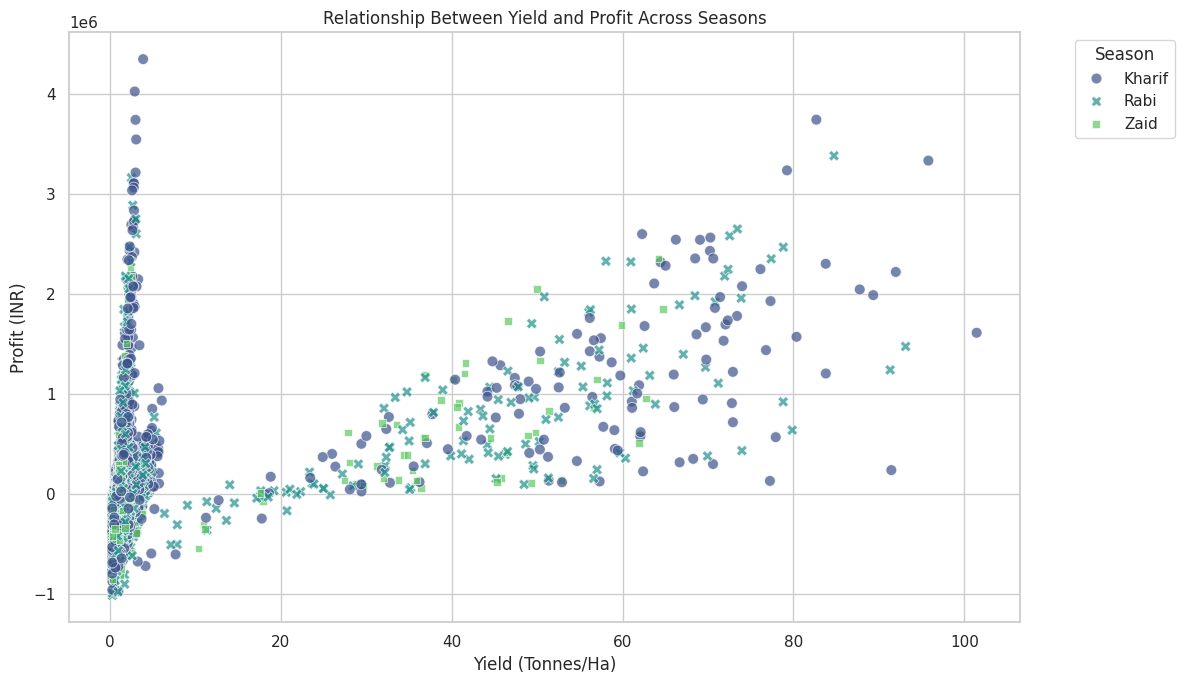

In [73]:
# Multivariate Analysis: Profit, Yield, and Season
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    hue='Season',
    style='Season',
    palette='viridis',
    alpha=0.7,
    s=60
)

plt.title('Relationship Between Yield and Profit Across Seasons')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Profit (INR)')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

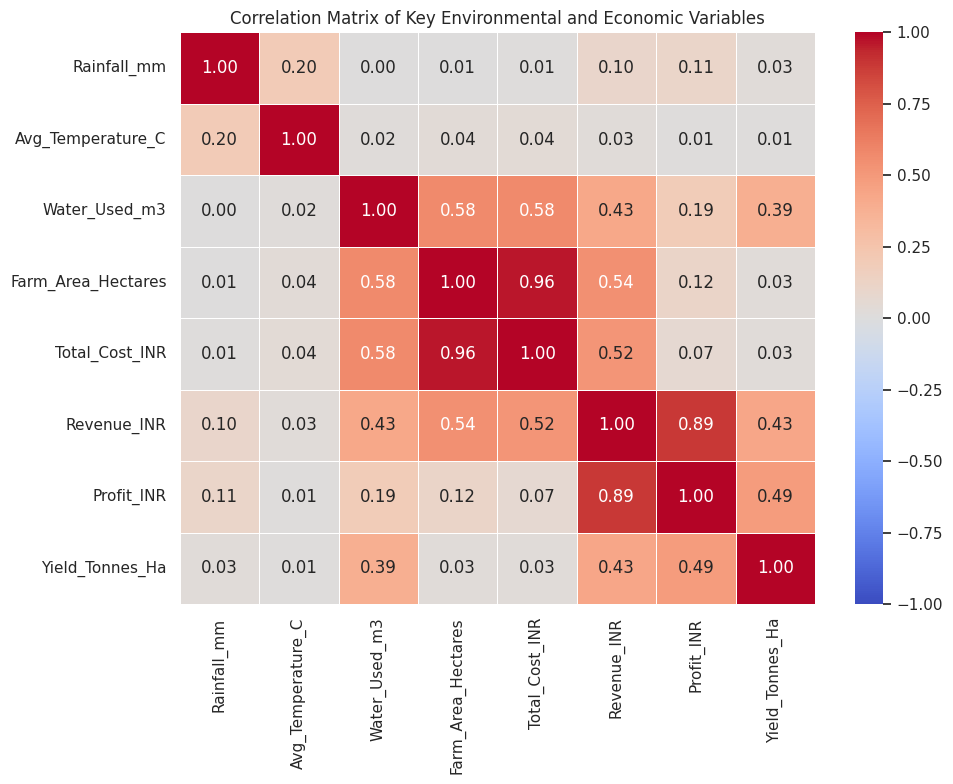

In [70]:
# Select a subset of highly relevant numerical variables
key_vars = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Water_Used_m3',
    'Farm_Area_Hectares', 'Total_Cost_INR', 'Revenue_INR',
    'Profit_INR', 'Yield_Tonnes_Ha'
]

# Calculate the correlation matrix
corr_matrix = df[key_vars].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix of Key Environmental and Economic Variables')
plt.tight_layout()
plt.show()

**12.SEASONAL COMPARISON**

In [78]:
# --- 1 Seasonal Comparison Table ---

seasonal_comparison_vars = [
    'Rainfall_mm', 'Water_Used_m3', 'Yield_Tonnes_Ha',
    'Total_Cost_INR', 'Revenue_INR', 'Profit_INR'
]

# Calculating mean and median grouped by Season
seasonal_summary_table = df.groupby('Season')[seasonal_comparison_vars].agg(['mean', 'median'])

# Display the structured comparison table
print("Structured Seasonal Comparison Table (Mean & Median):")
display(seasonal_summary_table)





Structured Seasonal Comparison Table (Mean & Median):


Rainfall_mm        Water_Used_m3          Yield_Tonnes_Ha         \
              mean median          mean   median            mean median   
Season                                                                    
Kharif      849.20 853.10      6,102.20 4,469.00            5.63   1.94   
Rabi        437.62 432.20      5,846.99 4,292.00            5.04   1.67   
Zaid        304.65 288.20      6,419.89 4,805.00            4.64   1.46   

       Total_Cost_INR            Revenue_INR            Profit_INR             
                 mean     median        mean     median       mean     median  
Season                                                                         
Kharif     531,804.41 524,840.00  710,719.06 520,196.00 178,914.65  38,808.00  
Rabi       513,836.58 506,733.00  601,526.05 438,156.00  87,689.47  -3,187.00  
Zaid       543,976.73 534,833.00  519,171.90 373,700.50 -24,804.82 -62,144.00

Text(0, 0.5, 'Average Revenue (INR)')

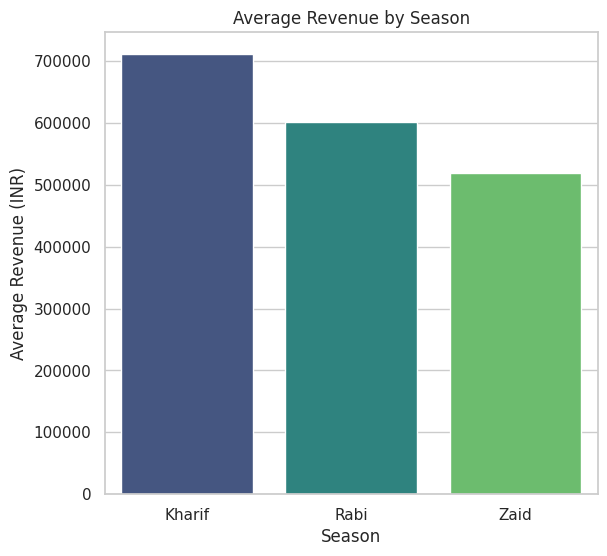

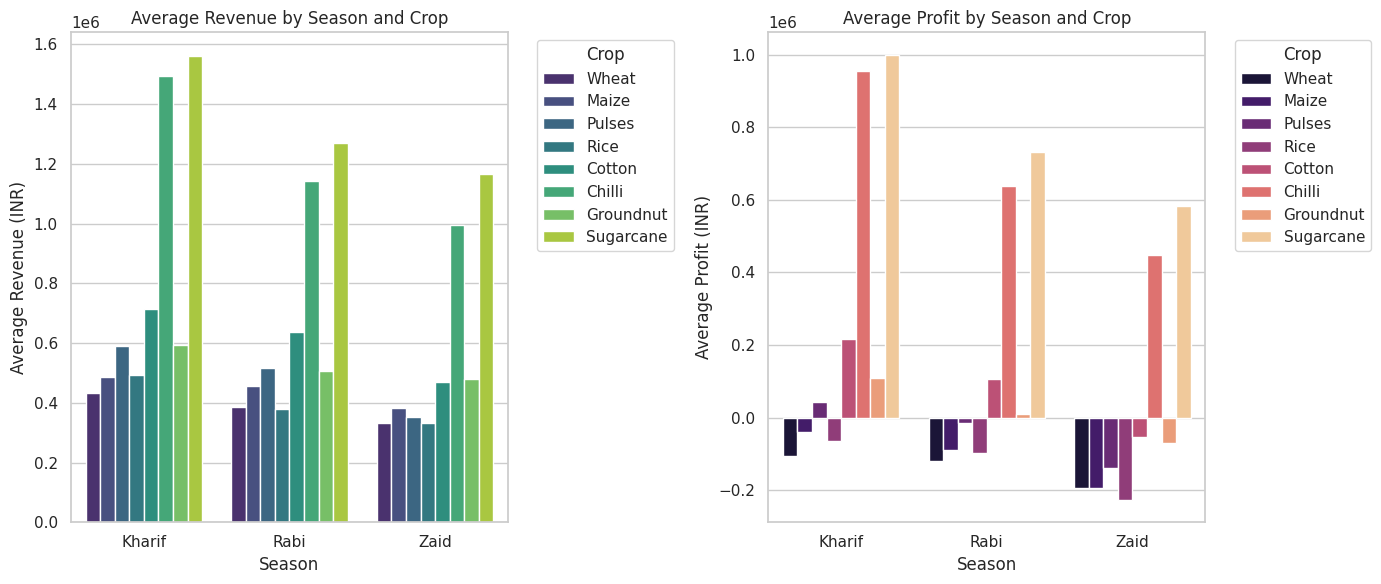

In [80]:
# Crop Performance by Season (Revenue and Profit)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Season', y='Revenue_INR', hue='Crop', palette='viridis', errorbar=None)
plt.title('Average Revenue by Season and Crop')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Season', y='Profit_INR', hue='Crop', palette='magma', errorbar=None)
plt.title('Average Profit by Season and Crop')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**13.ADDITIONAL ANYLYSIS**

**1.Regional Vulnerability to Disease and Pest Risk**

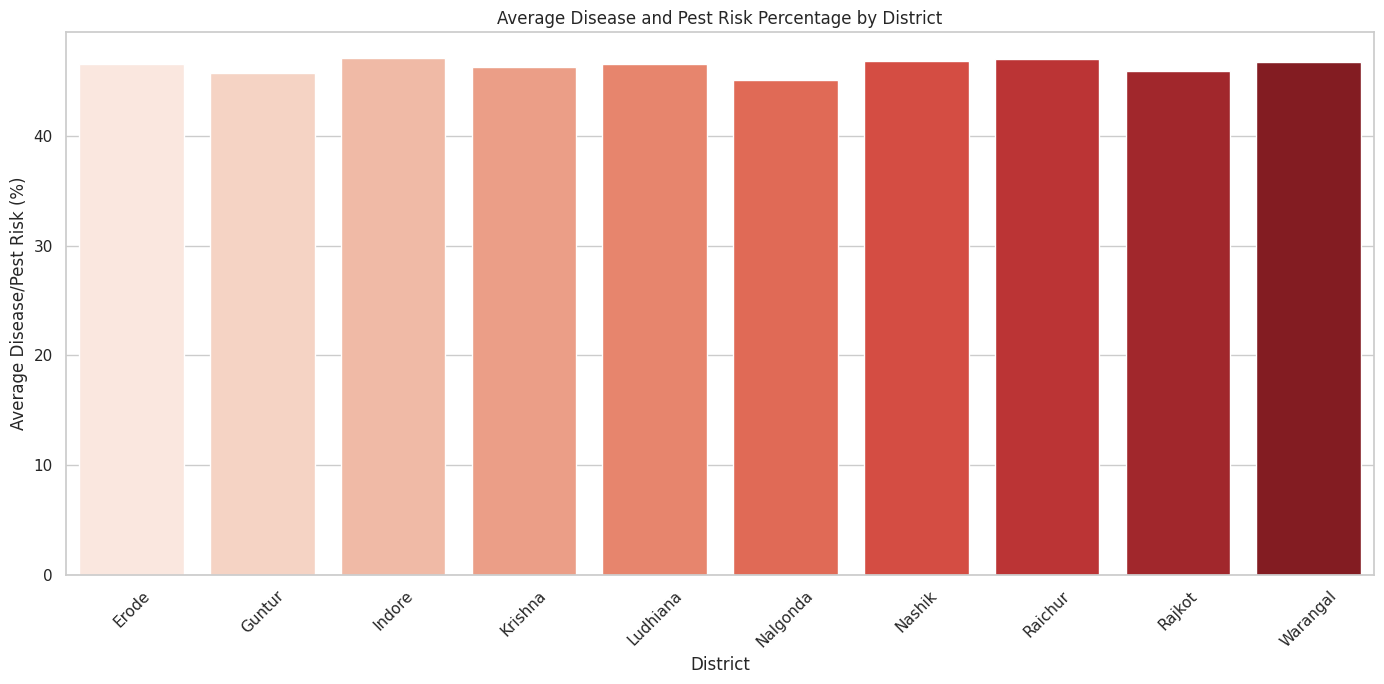

In [83]:
#  Regional Vulnerability to Disease and Pest Risk
plt.figure(figsize=(14, 7))

# Grouping by District to calculate mean humidity, temperature, and pest risk
district_pest_summary = df.groupby('District')[['Humidity_pct', 'Avg_Temperature_C', 'Disease_Pest_Risk_pct', 'Pesticide_Litre_ha']].mean().reset_index()


sns.barplot(
    data=district_pest_summary,
    x='District',
    y='Disease_Pest_Risk_pct',
    hue='District',
    palette='Reds',
    legend=False,
    errorbar=None
)

plt.title('Average Disease and Pest Risk Percentage by District')
plt.xlabel('District')
plt.ylabel('Average Disease/Pest Risk (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**2.Resource Efficiency Optimization (Water vs. Yield)**

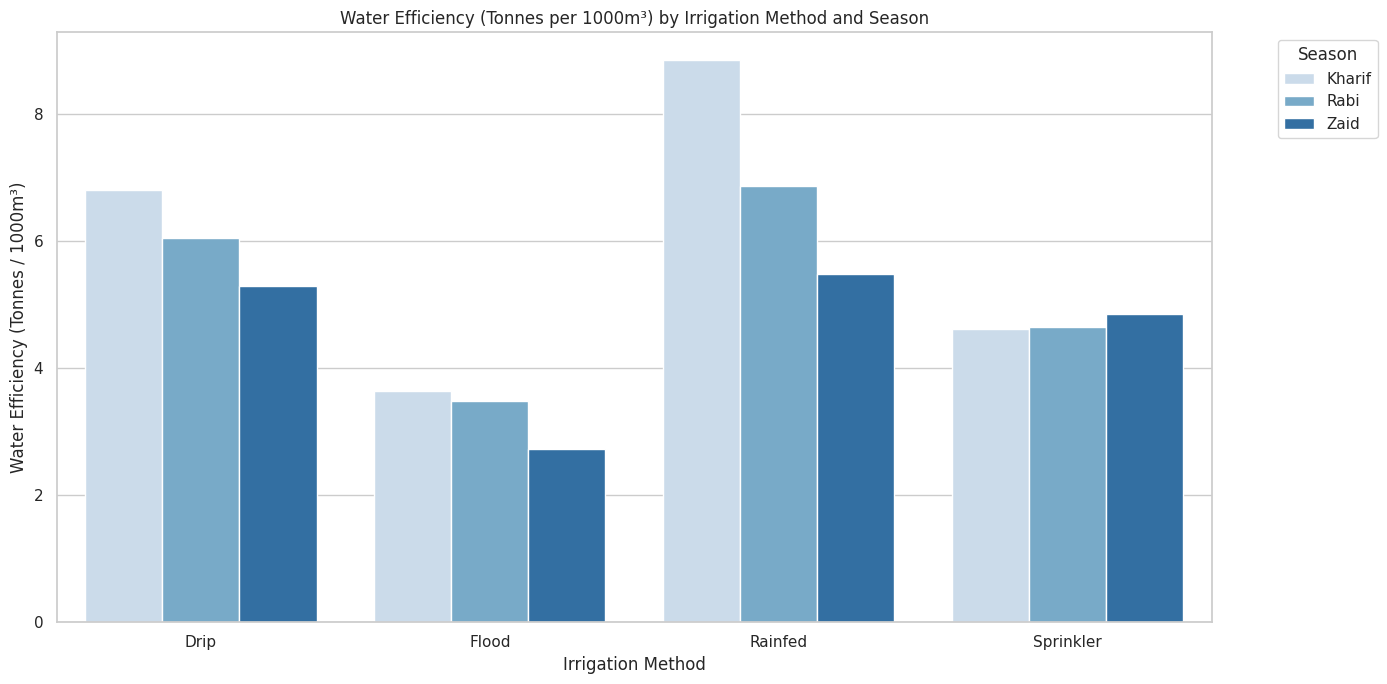

In [84]:
#  Resource Efficiency Optimization (Water vs. Yield)
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Water_Efficiency_t_per_1000m3',
    hue='Season',
    palette='Blues',
    errorbar=None
)

plt.title('Water Efficiency (Tonnes per 1000m³) by Irrigation Method and Season')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes / 1000m³)')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**3. Economic Return vs. Water Consumption Intensity**

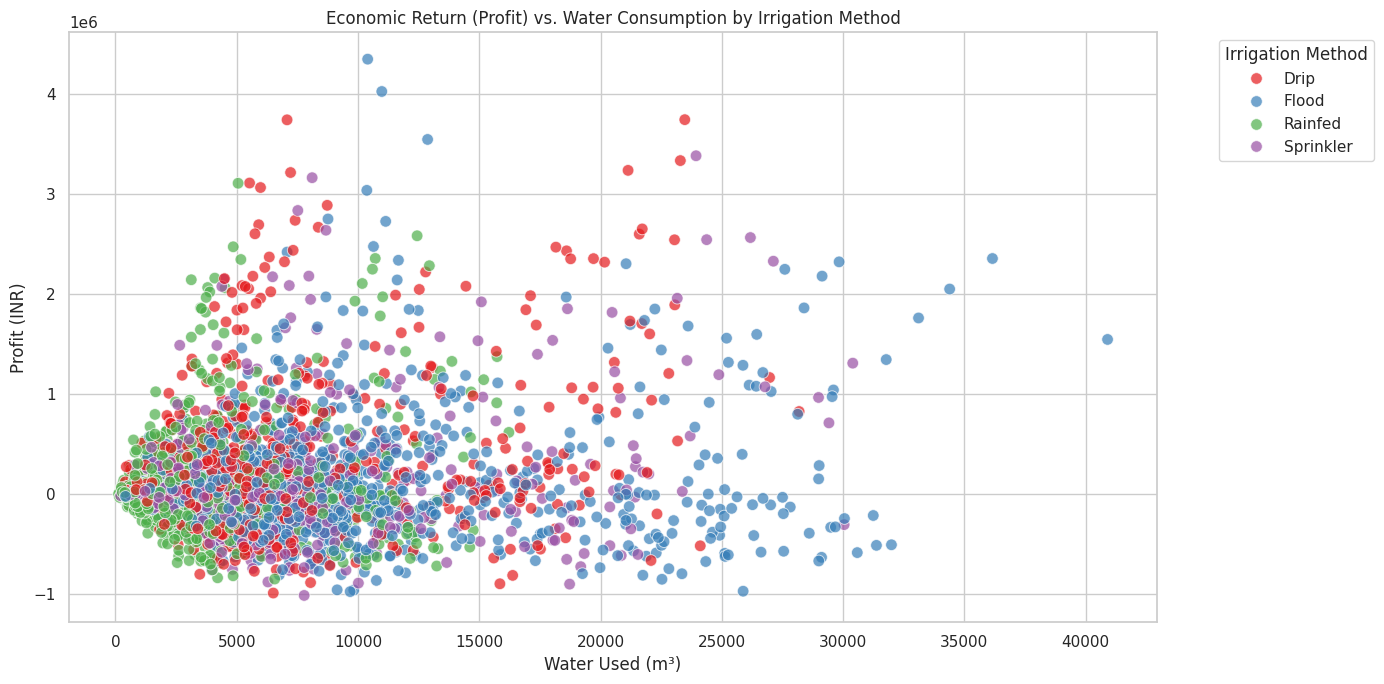

In [85]:
#  Economic Return vs. Water Consumption Intensity
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Profit_INR',
    hue='Irrigation_Method',
    palette='Set1',
    alpha=0.7,
    s=70
)

plt.title('Economic Return (Profit) vs. Water Consumption by Irrigation Method')
plt.xlabel('Water Used (m³)')
plt.ylabel('Profit (INR)')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**14.KEY INSIGHTS**


**1.Seasonal Impact on Farming Activity**  

*   **Observation**: Farming activity volume is heavily skewed toward the Kharif season, which captures the highest concentration of total farm records compared to Rabi and Zaid
*   **Evidence**: The univariate season distribution countplot and pie chart demonstrate that Kharif acts as the dominant seasonal period across the dataset.

*   **Interpretation**: Agricultural operations in this sample rely heavily on monsoon conditions for planting schedules.

*   **Limitation**: This indicates a seasonal concentration in our records, but it does not mean farming is impossible or non-existent during other periods.








**2.Crop-Specific Yield Scaling**


*  **Observation**: Physical yield distributions contain extreme upper-bound outliers reaching up to 100 tonnes per hectare, heavily driven by specific crop types.

*   **Evidence**: The univariate yield histogram alongside the IQR statistical summary and top-5 outlier inspection identify heavy crops like Sugarcane dominating the upper scale.
*   **Interpretation**: Biological weight differences across crop varieties dictate output weight far more than standard acreage scaling alone.


*  **Limitation**: High yield tonnage does not automatically translate to high net financial profit due to scaling input overheads.


**3.Economic Volatility and Break-Even Risk**


*   **Observation**: Net profit distributions span massive negative losses as well as extreme positive gains, with a median hovering near zero.

* ** Evidence**: The profit distribution histogram and boxplot incorporating the zero break-even line confirm widespread financial variance.
*  **Interpretation**: Farming operations exhibit a high-risk, high-variance economic profile where a substantial portion of farms operate near or below break-even.


*  **Limitation**: Negative profit margins reflect recorded operational costs and revenues in this sample, but do not account for external subsidies or off-season income streams.


**4.Rainfall Dependency vs. Artificial Irrigation**


*   **Observation**:Natural rainfall averages highest during Kharif, whereas Zaid and Rabi seasons demand significantly higher artificial water input.

*   ** Evidence**:The structured seasonal comparison table and bivariate seasonal water usage bar/box plots quantify these shifts.
*   **Interpretation**: Farmers must actively bridge environmental water deficits with artificial irrigation during drier months to sustain crop health.


*   **Limitation**:Higher water usage is associated with drier seasons, but this association does not prove that increased watering alone guarantees successful yields.


**5.Revenue Versus Net Profit Disparity**


*   **Observation**:Cash crops like Sugarcane and Chilli consistently achieve the highest average revenues exceeding 1.0M INR, yet net profits vary drastically.
*   **Evidence**:The multivariate crop-by-season performance bar plots display high revenue bars coupled with compressed or negative profit margins.

*   **Interpretation**:High gross income for cash crops is frequently offset by heavy seasonal overhead, fertilizer, and irrigation expenditures.
*   **Limitation**:High revenue indicates strong market turnover, but should not be mistaken for guaranteed financial viability without subtracting total production costs.




**6.Regional Environmental Pest Vulnerability**
*   **Observation**:Specific districts experiencing high ambient temperatures paired with elevated humidity report significantly higher disease-pest risk percentages.

*   **Evidence**:The district-level pest risk summary bar chart highlights localized clusters exceeding baseline vulnerability thresholds.
*   **Interpretation**:Micro-climatic environmental conditions strongly correlate with pest and disease pressures, necessitating targeted protection strategies.


*   **Limitation**:Climate patterns correlate with pest risk percentages, but environmental conditions alone do not cause pest outbreaks without biological vectors present.




**7. Water Efficiency Disparities Across Irrigation Methods**


*   **Observation**:Water efficiency metrics vary widely between traditional flood methods and modern micro-irrigation systems across different seasons.

*   **Evidence**:The resource efficiency optimization bar plots tracking tonnes per $1000m^3$ demonstrate distinct efficiency tiers.
*   **Interpretation**:Modern irrigation techniques deployed during low-rainfall windows optimize water productivity relative to total volume consumed.


*   **Limitation**:Higher water efficiency metrics indicate resource optimization, but do not imply that every farm can immediately transition infrastructure without capital investment.



**8.Farm Area vs. Production Scaling Limits**


*   **Observation**:Total production weight scales unevenly with farm area, stratified heavily by the underlying crop selection.

*   **Evidence**:The bivariate scatter plot mapping farm area against total production categorized by crop highlights distinct vertical stratification layers.
*   **Interpretation**:Physical land size is secondary to crop type when determining total harvest weight, as heavy crops generate massive tonnage even on moderate plots.


*  **Limitation**:Larger land acreage provides spatial capacity, but larger area does not inherently cause higher productivity per hectare.
















**15.RECOMMENDATION**



**1.  Optimize Water Allocation During Drier Seasons**


*   **Recommendation**: Transition water-intensive crops in dry seasons toward efficient micro-irrigation systems or adjust planting calendars to align with natural monsoon cycles.

*   **Observed Finding**: The seasonal comparison table and seasonal water usage plots show that Zaid and Rabi seasons experience severe natural rainfall deficits while demanding drastically higher artificial water input ($Water\_Used\_m3$).
* **Data-Supported Rationale**: Water efficiency metrics and scatter plots confirm that modern irrigation techniques significantly boost water productivity relative to total volume consumed.  


*   **Important Limitation**: While switching to drip or sprinkler systems improves resource efficiency, this recommendation assumes capital accessibility and does not prove that upgrading infrastructure alone guarantees positive net financial profit across all farm sizes.


2.   **Mitigate Pest Vulnerabilities Using Micro-Climatic Tracking**


*   **Recommendation**:Establish targeted pest management protocols tailored specifically to districts experiencing high ambient temperature and humidity combinations.
*  **Observed Finding**:District-level summaries and multivariate environmental indicators demonstrate that regions with high humidity and elevated temperatures report disease and pest risk percentages frequently exceeding 60%.


*  **Data-Supported Rationale**:High risk percentages directly drive up pesticide usage requirements ($Pesticide\_Litre\_ha$) and total production costs.
*   **Important Limitation**:Environmental conditions correlate with elevated pest risk percentages, but climate data alone do not cause outbreaks without underlying biological vectors present.


3.   **Balance Cash Crop Revenue Targets Against Overhead Exposure**


*   **Recommendation**:Conduct rigorous cost-benefit reviews before expanding acreage for high-revenue cash crops during off-peak seasons.

*   **Observed Finding**:Multivariate analysis of crop-by-season performance reveals that cash crops like Sugarcane and Chilli consistently generate massive average revenues exceeding 1.0M INR, yet net profit distributions exhibit extreme financial variance and widespread negative values near break-even lines.
*   **Data-Supported Rationale**:High gross earnings are frequently offset by heavy seasonal overhead, fertilizer, and irrigation expenditures.


*   **Important Limitation**:High market turnover indicates strong gross revenue, but should not be mistaken for guaranteed net profitability without factoring in localized production costs and market price fluctuations.












**16.CONCLUSION**

**Seasonal Agricultural Performance Analysis**


*   **Dataset Insights on Seasonality**: The dataset demonstrated that farming activity and natural environmental conditions are heavily concentrated in the Kharif monsoon season, which dictates baseline planting volumes compared to drier Rabi and Zaid periods.

*   **Most Important Patterns Discovered**: High-revenue cash crops like Sugarcane and Chilli generate massive gross returns exceeding 1.0M INR, but their net profitability is tightly constrained by seasonal overhead, elevated fertilizer use, and heavy artificial irrigation demands during dry months.
*   **Most Useful Analytical Findings**: Multivariate and district-level analyses revealed that micro-climatic combinations of high temperature and humidity heavily correlate with disease-pest risks exceeding 60%, while modern micro-irrigation systems significantly improve water productivity metrics ($t/1000m^3$) compared to traditional flood methods.


*   **Important Limitations of the Analysis**: The findings rely entirely on observational patterns and historical correlations within this specific sample, meaning they demonstrate associations rather than proving direct cause-and-effect, and they exclude external variables like market price volatility or capital equipment costs.

*  **Support for Future Decision-Making**: These insights can guide future agricultural planning by helping stakeholders target region-specific pest management protocols, optimize water allocation toward water-efficient irrigation systems during dry seasons, and balance high gross revenue targets against underlying production cost exposures.




